# Import Statements

In [2]:
import pickle
import numpy as np
import pandas as pd
import scipy
import sklearn
import shap
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm as notebook_tqdm
import skopt
import copy

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from scipy import stats
from math import sqrt
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import Ridge

In [4]:
print(np.__version__)

1.26.3


# Define functions

In [5]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

rr_space = {
    "alpha": Real(1e-5, 1e2, prior="log-uniform")
}

lasso_space = {
    'alpha': Real(1e-5, 1.0, 'log-uniform')  # L1 penalty term
}

In [6]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [7]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor(n_jobs=1)
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_lasso_search(X, y, lasso_space):
    lasso = Lasso(max_iter=100000)
    lasso_bayes_search = BayesSearchCV(
        estimator=lasso,
        search_spaces=lasso_space,
        scoring=None,
        cv=5,
        n_iter=10,  # number of iterations to try
        random_state=42,
        verbose=1,
        n_jobs=-1
)
    lasso_bayes_search.fit(X, y)
    
    print("Best Lasso hyperparameters:", lasso_bayes_search.best_params_)
    
    best_params = lasso_bayes_search.best_params_
    best_lasso = Lasso(**best_params)

    return best_lasso



In [8]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, X, y, k):
    """
    Evaluates model using k-fold CV and returns the final model trained on full dataset.
    
    Parameters:
    m: model (e.g., XGBoost or RandomForest) with best hyperparameters
    X: feature matrix
    y: labels
    k: number of folds
    """
    cv = KFold(n_splits=k, shuffle=True)
    rmse_results = []
    percent_rmse_results = []
    r2_results = []
 
    low = 100
    best_fold_model = None
    
    for fold, (train, test) in enumerate(cv.split(X, y), start=1):
        print(f"\n=== Fold {fold} ===")
        
        m.fit(X[train], y[train].ravel())
        preds = m.predict(X[test])
        
        ss = sqrt(mean_squared_error(y[test], preds))  
        rr = r2_score(y[test], preds)                  
        mm = np.mean(y[test])
        error_mean = (ss / mm) * 100
        
        rmse_results.append(ss)
        percent_rmse_results.append(error_mean)
        r2_results.append(rr)
        
        print(f"R²: {rr:.4f}, RMSE: {ss:.4f}, %RMSE: {error_mean:.2f}")
        
        if error_mean < low:
            low = error_mean
            best_fold_model = copy.deepcopy(m)
    
    print("\nCV Summary:")
    print(f"Mean %RMSE: {np.mean(percent_rmse_results):.2f} ± {np.std(percent_rmse_results):.2f}")
    
    # Plot %RMSE per fold
    plt.figure(figsize=(8,5), dpi=300)
    cb_palette = ["#E69F00", "#56B4E9", "#009E73"]
    plt.plot(range(1, k+1), percent_rmse_results, marker="o", label="%RMSE", color=cb_palette[0])
    plt.plot(range(1, k+1), rmse_results, marker="s", label="RMSE", color=cb_palette[1])
    plt.plot(range(1, k+1), r2_results, marker="^", label="R²", color=cb_palette[2])
    plt.xlabel("Fold Number")
    plt.ylabel("Metric Value")
    plt.title("Cross-Validation Metrics per Fold")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Retrain the best model on full dataset
    final_model = copy.deepcopy(best_fold_model)
    final_model.fit(X, y.ravel())
    
    metrics = {
        "RMSE": rmse_results,
        "%RMSE": percent_rmse_results,
        "R2": r2_results
    }
    
    return final_model, metrics

#TO RUN - best_model_xgb, results = eval_k_fold(model, X, y, 10)

In [9]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [10]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting (no artificial filters)
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6), dpi=300)
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [11]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

In [12]:
class MultiInputStackingRegressor(BaseEstimator, RegressorMixin):
    def __init__(
        self,
        base_models,
        meta_model=None,
        n_folds=10,
        random_state=42
    ):
        """
        base_models: list of regressors (tuned XGBoost models)
        meta_model: Ridge regression
        """
        self.base_models = base_models
        self.meta_model = meta_model or Ridge(alpha=1.0)
        self.n_folds = n_folds
        self.random_state = random_state

    def fit(self, X_list, y):
        """
        X_list: [X1, X2, X3]
        y: target array
        """
        self.base_models_ = [list() for _ in self.base_models]
        self.meta_features_ = np.zeros((len(y), len(self.base_models)))

        cv = KFold(
            n_splits=self.n_folds,
            shuffle=True,
            random_state=self.random_state
        )

        for i, model in enumerate(self.base_models):
            for train_idx, val_idx in cv.split(y):
                X_train = X_list[i][train_idx]
                X_val = X_list[i][val_idx]

                model_clone = model.__class__(**model.get_params())
                model_clone.fit(X_train, y[train_idx])
                preds = model_clone.predict(X_val)

                self.meta_features_[val_idx, i] = preds
                self.base_models_[i].append(model_clone)

        self.meta_model.fit(self.meta_features_, y)
        return self

    def predict(self, X_list):
        """
        X_list: [X1, X2, X3]
        """
        meta_features = np.column_stack([
            np.mean(
                [model.predict(X_list[i]) for model in self.base_models_[i]],
                axis=0
            )
            for i in range(len(self.base_models_))
        ])

        return self.meta_model.predict(meta_features)

#The base models are fitted on k-1 folds and make predictions on the remaining fold, that way there's no leakage.
#because the meta model takes predictions of the base model as its input so if the predictions are overfitted then no use. 
#therefore, cv is used iteratevely so there's predictions of every data point (hence the model_clone)

# Run Lasso model

## Load datasets

In [13]:
gene_pav = pd.read_pickle("../genotype/gene_pav_LASSO_yield_training_data.pkl")

In [14]:
gene_pav.head()

,GlymaLee.01G030900.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G022100.1.v1.1,GlymaLee.03G067500.1.v1.1,GlymaLee.05G034800.1.v1.1,GlymaLee.06G038900.1.v1.1,GlymaLee.06G241100.1.v1.1,GlymaLee.07G058300.1.v1.1,GlymaLee.07G060200.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,1,1,0,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02_SOYBEAN.EVALUATION.MS2001_02,0,1,1,1,1,1,1,0,1,0,...,0,0,1,0,0,0,0,0,0,1.30
BR-01_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.33
BR-13_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.15
BR-14_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,2.87


In [15]:
gene_pav['Data-storage-ID'] = gene_pav.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
gene_pav = gene_pav.reset_index(drop=True).set_index('Data-storage-ID')
gene_pav.head()

,GlymaLee.01G030900.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G022100.1.v1.1,GlymaLee.03G067500.1.v1.1,GlymaLee.05G034800.1.v1.1,GlymaLee.06G038900.1.v1.1,GlymaLee.06G241100.1.v1.1,GlymaLee.07G058300.1.v1.1,GlymaLee.07G060200.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,0,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02,0,1,1,1,1,1,1,0,1,0,...,0,0,1,0,0,0,0,0,0,1.30
BR-01,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.33
BR-13,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.15
BR-14,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,2.87


In [16]:
gene_pav.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, AB-01 to USB-818
Columns: 203 entries, GlymaLee.01G030900.1.v1.1 to observation_value
dtypes: float64(1), int64(31), object(171)
memory usage: 1.2+ MB


In [17]:
pav1 = gene_pav.iloc[:, 0:202]
pav1.head()

,GlymaLee.01G030900.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G022100.1.v1.1,GlymaLee.03G067500.1.v1.1,GlymaLee.05G034800.1.v1.1,GlymaLee.06G038900.1.v1.1,GlymaLee.06G241100.1.v1.1,GlymaLee.07G058300.1.v1.1,GlymaLee.07G060200.1.v1.1,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,0,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,0,1,1,1,1,1,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
BR-01,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
BR-13,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
BR-14,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0


In [18]:
y2 = gene_pav["observation_value"]
y2.head()

Data-storage-ID
AB-01    1.54
AB-02    1.30
BR-01    4.33
BR-13    4.15
BR-14    2.87
Name: observation_value, dtype: float64

In [19]:
snp = pd.read_pickle("../genotype/lasso_SNP_yield_training_data.pkl")

In [20]:
#snp = pd.read_pickle("../genotype/SNP_yield_holdout_data.pkl")

In [21]:
snp['Data-storage-ID'] = snp.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp = snp.reset_index(drop=True).set_index('Data-storage-ID')
snp.head()

,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,2,0,0,2,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02,0,0,2,0,0,2,0,0,0,2,...,0,0,1,0,0,0,0,0,0,1.30
BR-01,2,0,0,2,0,0,0,0,2,0,...,0,0,0,0,1,0,0,0,0,4.33
BR-13,2,0,0,2,0,0,0,0,2,2,...,0,0,0,0,1,0,0,0,0,4.15
BR-14,2,0,2,2,0,0,0,0,2,2,...,0,0,0,0,1,0,0,0,0,2.87


In [22]:
snp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, AB-01 to USB-818
Columns: 207 entries, Gm01_553130 to observation_value
dtypes: float64(1), int64(206)
memory usage: 1.3+ MB


In [23]:
snp1 = snp.iloc[:, 0:206]
snp1.head()

,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,2,0,0,2,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,0,0,2,0,0,2,0,0,0,2,...,0,0,0,1,0,0,0,0,0,0
BR-01,2,0,0,2,0,0,0,0,2,0,...,0,0,0,0,0,1,0,0,0,0
BR-13,2,0,0,2,0,0,0,0,2,2,...,0,0,0,0,0,1,0,0,0,0
BR-14,2,0,2,2,0,0,0,0,2,2,...,0,0,0,0,0,1,0,0,0,0


In [24]:
y1 = snp["observation_value"]
y1.head()

Data-storage-ID
AB-01    1.54
AB-02    1.30
BR-01    4.33
BR-13    4.15
BR-14    2.87
Name: observation_value, dtype: float64

In [25]:
cov = snp.iloc[:,-32:]
cov.head()

,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,SOYBEAN.EVALUATION.3IL83.2,SOYBEAN.EVALUATION.3IL84,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1.30
BR-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,4.33
BR-13,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,4.15
BR-14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,2.87


In [26]:
cov = cov.drop(columns=['observation_value'])
cov.head()

,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,SOYBEAN.EVALUATION.3IL83.2,SOYBEAN.EVALUATION.3IL84,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
BR-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
BR-13,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
BR-14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [27]:
y_final = snp["observation_value"]
y_final.head()

Data-storage-ID
AB-01    1.54
AB-02    1.30
BR-01    4.33
BR-13    4.15
BR-14    2.87
Name: observation_value, dtype: float64

In [28]:
pfam = pd.read_pickle("../genotype/pfam_pav_newIDs_eval5_varthreshold_lasso_yield_training_data.pkl")

In [29]:
#pfam = pd.read_pickle("../genotype/pfam_pav_newIDs_eval5_varthreshold_holdout_data_pav.pkl")

In [30]:
pfam['Data-storage-ID'] = pfam.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam = pfam.reset_index(drop=True).set_index('Data-storage-ID')
pfam.head()

,PF00931_01G030900,PF00332_01G044800,PF10440_03G049800,PF13855_06G038900,PF01582_06G230600,PF02519_06G240800,PF05056_07G058300,PF02548_07G058400,PF05056_07G060200,PF00450_07G184300,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02,0,1,1,1,1,0,1,0,0,1,...,0,0,1,0,0,0,0,0,0,1.30
BR-01,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.33
BR-13,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.15
BR-14,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,2.87


In [31]:
pfam1 = pfam.iloc[:, 0:156]
pfam1.head()

,PF00931_01G030900,PF00332_01G044800,PF10440_03G049800,PF13855_06G038900,PF01582_06G230600,PF02519_06G240800,PF05056_07G058300,PF02548_07G058400,PF05056_07G060200,PF00450_07G184300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,0,1,1,1,1,0,1,0,0,1,...,0,0,0,1,0,0,0,0,0,0
BR-01,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
BR-13,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
BR-14,1,1,1,1,0,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0


In [32]:
pfam1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, AB-01 to USB-818
Columns: 156 entries, PF00931_01G030900 to SOYBEAN.EVALUATION.MS989
dtypes: int64(156)
memory usage: 984.9+ KB


In [33]:
y3 = pfam["observation_value"]
y3.head()

Data-storage-ID
AB-01    1.54
AB-02    1.30
BR-01    4.33
BR-13    4.15
BR-14    2.87
Name: observation_value, dtype: float64

## Hyperparameter tuning of base models

### Base model for snps

In [34]:
X_all = snp1.values
y_all = y1.values

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [36]:
snp_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.7100847105421485), ('colsample_bytree', 0.8553028774465524), ('gamma', 0.49999999999999994), ('learning_rate', 0.02734416917316165), ('max_delta_step', 5), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 200), ('reg_alpha', 1.960518820386933e-08), ('reg_lambda', 1.01715929816139e-08), ('subsample', 0.237843469115754)])


### Base model for pav

In [37]:
X_all = pav1.values
y_all = y2.values

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [39]:
pav_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


### Base model for pfam

In [40]:
X_all = pfam1.values
y_all = y3.values

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [42]:
pfam_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.3718270634215103), ('colsample_bytree', 1.0), ('gamma', 5.609923134071703e-09), ('learning_rate', 0.04508408749151527), ('max_delta_step', 9), ('max_depth', 16), ('min_child_weight', 9), ('n_estimators', 160), ('reg_alpha', 1.1013264802639234e-05), ('reg_lambda', 0.026247459441955348), ('subsample', 0.9141228426708968)])


## Stacking

In [43]:
base_models = [
    snp_xgbreg,
    pav_xgbreg,
    pfam_xgbreg
]

In [44]:
X1 = snp1.to_numpy()
X2 = pav1.to_numpy()
X3 = pfam1.to_numpy()

In [45]:
stack_model = MultiInputStackingRegressor(
    base_models=base_models,
    meta_model=Ridge(alpha=1.0),
    n_folds=5
)

In [46]:
stack_model.fit([X1, X2, X3], y_final)

/tmp/ipykernel_3906693/3372023707.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_clone.fit(X_train, y[train_idx])


MultiInputStackingRegressor(base_models=[XGBRegressor(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=0.7100847105421485,
                                                      colsample_bynode=None,
                                                      colsample_bytree=0.8553028774465524,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=0.49999999999999994,
                                                      grow_polic...
                                                      importance_type=None,
                                                      interaction_constraints=None,
                                                      learning_rate=0.04508408749151527,
                                                      max_bin=None,
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=9,
                                                      max_depth=16,
                                                      max_leaves=None,
                                                      min_child_weight=9,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=160,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...)],
                            meta_model=Ridge(), n_folds=5)

In [47]:
meta_df = pd.DataFrame(
    stack_model.meta_features_,
    columns=["SNP_pred", "PAV_pred", "Pfam_pred"]
)
meta_df.to_pickle("meta_features_LASSO_so.pkl")
meta_df.head()

,SNP_pred,PAV_pred,Pfam_pred
0,1.664206,2.065696,1.937524
1,1.507371,1.589339,2.238437
2,3.479941,3.505497,3.368993
3,3.066894,3.365826,3.304137
4,3.361333,3.402014,3.796902


In [48]:
meta_df.describe()

,SNP_pred,PAV_pred,Pfam_pred
count,803.000000,803.000000,803.000000
mean,2.262452,2.269268,2.260525
std,0.701092,0.610564,0.627902
min,0.391841,0.636567,0.613676
25%,1.770743,1.832134,1.804431
50%,2.237445,2.236743,2.216653
75%,2.736690,2.663867,2.669255
max,4.228672,4.350679,4.212721


In [49]:
meta_df.corr()

,SNP_pred,PAV_pred,Pfam_pred
SNP_pred,1.000000,0.910647,0.868517
PAV_pred,0.910647,1.000000,0.909397
Pfam_pred,0.868517,0.909397,1.000000


In [50]:
from scipy.stats import pearsonr

corr_matrix = meta_df.corr()

p_matrix = pd.DataFrame(index=meta_df.columns, columns=meta_df.columns)

for col1 in meta_df.columns:
    for col2 in meta_df.columns:
        r, p = pearsonr(meta_df[col1], meta_df[col2])
        p_matrix.loc[col1, col2] = p

print("Correlation matrix:")
print(corr_matrix)

print("\nP-value matrix:")
print(p_matrix)

Correlation matrix:
           SNP_pred  PAV_pred  Pfam_pred
SNP_pred   1.000000  0.910647   0.868517
PAV_pred   0.910647  1.000000   0.909397
Pfam_pred  0.868517  0.909397   1.000000

P-value matrix:
          SNP_pred PAV_pred Pfam_pred
SNP_pred       0.0      0.0       0.0
PAV_pred       0.0      0.0       0.0
Pfam_pred      0.0      0.0       0.0


In [51]:
meta_search = BayesSearchCV(
    estimator=Ridge(),
    search_spaces=rr_space,
    n_iter=10,  # usually enough for 1D
    cv=5,
    scoring=None,
    random_state=42,
    n_jobs=-1
)

meta_search.fit(stack_model.meta_features_, y_final)

BayesSearchCV(cv=5, estimator=Ridge(), n_iter=10, n_jobs=-1, random_state=42,
              search_spaces={'alpha': Real(low=1e-05, high=100.0, prior='log-uniform', transform='normalize')})

In [52]:
stack_model.meta_model = meta_search.best_estimator_

## Testing

In [53]:
holdout = pd.read_pickle("../genotype/snp_pav_pfam_yield_holdout_varthreshold.pkl")

In [54]:
holdout.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
ESS_SOYBEAN.EVALUATION.MS1999_01,1,0,0,0,0,1,1,0,0,0,...,1,0,0,0,0,0,0,0,0,3.60
HN012_SOYBEAN.EVALUATION.IL945,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.86
HN018_SOYBEAN.EVALUATION.3IL83.2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.87
HN037_SOYBEAN.EVALUATION.1IL64,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.88
HN060_SOYBEAN.EVALUATION.4IL87,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,2.02


In [55]:
snp_holdout = holdout[snp1.columns]

In [56]:
snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp_holdout = snp_holdout.reset_index(drop=True).set_index('Data-storage-ID')
snp_holdout.head()

/tmp/ipykernel_3906693/3552470459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]


,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,2,0,2,0,0,0,0,2,1,...,0,1,0,0,0,0,0,0,0,0
HN012,2,0,2,0,2,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN018,0,0,2,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN037,0,2,0,0,0,0,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0
HN060,2,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
pav_holdout = holdout[pav1.columns]

In [58]:
pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pav_holdout = pav_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pav_holdout.head()

/tmp/ipykernel_3906693/2899270742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]


,GlymaLee.01G030900.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G022100.1.v1.1,GlymaLee.03G067500.1.v1.1,GlymaLee.05G034800.1.v1.1,GlymaLee.06G038900.1.v1.1,GlymaLee.06G241100.1.v1.1,GlymaLee.07G058300.1.v1.1,GlymaLee.07G060200.1.v1.1,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
HN012,0,1,1,0,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
HN018,0,0,1,1,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
HN037,0,1,0,0,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
HN060,0,1,1,1,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
pfam_holdout = holdout[pfam1.columns]

In [60]:
pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam_holdout = pfam_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pfam_holdout.head()

/tmp/ipykernel_3906693/577540637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]


,PF00931_01G030900,PF00332_01G044800,PF10440_03G049800,PF13855_06G038900,PF01582_06G230600,PF02519_06G240800,PF05056_07G058300,PF02548_07G058400,PF05056_07G060200,PF00450_07G184300,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
HN012,0,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN018,0,0,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN037,0,1,0,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
HN060,0,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [61]:
cov_holdout = holdout[cov.columns]

In [62]:
cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
cov_holdout = cov_holdout.reset_index(drop=True).set_index('Data-storage-ID')
cov_holdout.head()

/tmp/ipykernel_3906693/403245011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]


,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,SOYBEAN.EVALUATION.3IL83.2,SOYBEAN.EVALUATION.3IL84,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
HN012,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN018,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
HN037,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN060,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [63]:
y_final_test = holdout['observation_value'].values

In [64]:
X1_test = snp_holdout.values
X2_test = pav_holdout.values
X3_test = pfam_holdout.values
X4_test = cov_holdout.values

In [65]:
y_pred = stack_model.predict([X1_test, X2_test, X3_test])

In [66]:
r2 = r2_score(y_final_test, y_pred)
print(f"R²: {r2:.4f}")

R²: 0.4854


In [67]:
mse = mean_squared_error(y_final_test, y_pred)
print(f"MSE: {mse:.4f}")

MSE: 0.3431


In [68]:
rmse = sqrt(mean_squared_error(y_final_test, y_pred))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.5857


In [165]:
r = np.corrcoef(y_final_test, y_pred)[0, 1]
print(f"Pearson r: {r:.4f}")

Pearson r: 0.7021


In [166]:
with open("stack_model_lasso_yield_withenv.dat", "wb") as f:
    pickle.dump(stack_model, f)

In [109]:
with open("stack_model_lasso_yield_withenv.dat", "rb") as f:
    stack_model = pickle.load(f)

In [167]:
X_test_list = [X1_test, X2_test, X3_test]  # same order as training

meta_features_test = np.column_stack([
    np.mean([model.predict(X_test_list[i]) for model in stack_model.base_models_[i]], axis=0)
    for i in range(len(stack_model.base_models_))
])

In [168]:
meta_model = stack_model.meta_model  # loaded or trained

In [169]:
explainer_meta = shap.LinearExplainer(meta_model, meta_features_test)

In [170]:
shap_values_meta = explainer_meta.shap_values(meta_features_test)

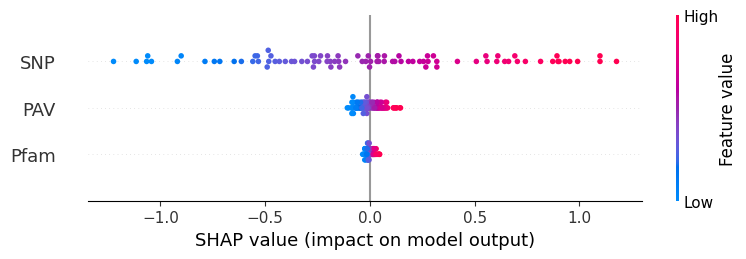

In [171]:
shap.summary_plot(shap_values_meta, meta_features_test, feature_names=["SNP", "PAV", "Pfam"], show=False)
plt.savefig(
    "stack_model_lasso_yield_withenv.png",
    dpi=600,
    bbox_inches="tight"
)

# Variance threshold models

## Load datasets

In [69]:
snp = pd.read_pickle("../genotype/lasso_SNP_yield_training_data.pkl")
snp.head()

,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,2,0,0,2,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02_SOYBEAN.EVALUATION.MS2001_02,0,0,2,0,0,2,0,0,0,2,...,0,0,1,0,0,0,0,0,0,1.30
BR-01_SOYBEAN.EVALUATION.MS2011_12,2,0,0,2,0,0,0,0,2,0,...,0,0,0,0,1,0,0,0,0,4.33
BR-13_SOYBEAN.EVALUATION.MS2011_12,2,0,0,2,0,0,0,0,2,2,...,0,0,0,0,1,0,0,0,0,4.15
BR-14_SOYBEAN.EVALUATION.MS2011_12,2,0,2,2,0,0,0,0,2,2,...,0,0,0,0,1,0,0,0,0,2.87


In [70]:
snp['Data-storage-ID'] = snp.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp = snp.reset_index(drop=True).set_index('Data-storage-ID')
snp.head()

,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,2,0,0,2,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02,0,0,2,0,0,2,0,0,0,2,...,0,0,1,0,0,0,0,0,0,1.30
BR-01,2,0,0,2,0,0,0,0,2,0,...,0,0,0,0,1,0,0,0,0,4.33
BR-13,2,0,0,2,0,0,0,0,2,2,...,0,0,0,0,1,0,0,0,0,4.15
BR-14,2,0,2,2,0,0,0,0,2,2,...,0,0,0,0,1,0,0,0,0,2.87


In [71]:
snp1 = snp.iloc[:, 0:206]
snp1.head()

,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,2,0,0,2,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,0,0,2,0,0,2,0,0,0,2,...,0,0,0,1,0,0,0,0,0,0
BR-01,2,0,0,2,0,0,0,0,2,0,...,0,0,0,0,0,1,0,0,0,0
BR-13,2,0,0,2,0,0,0,0,2,2,...,0,0,0,0,0,1,0,0,0,0
BR-14,2,0,2,2,0,0,0,0,2,2,...,0,0,0,0,0,1,0,0,0,0


In [72]:
y1 = snp["observation_value"]
y1.head()

Data-storage-ID
AB-01    1.54
AB-02    1.30
BR-01    4.33
BR-13    4.15
BR-14    2.87
Name: observation_value, dtype: float64

In [73]:
y_final = snp["observation_value"]
y_final.head()

Data-storage-ID
AB-01    1.54
AB-02    1.30
BR-01    4.33
BR-13    4.15
BR-14    2.87
Name: observation_value, dtype: float64

In [74]:
pav = pd.read_pickle("../genotype/gene_pav_afterFS_varthreshold_yield_training_data.pkl")
pav.head()

,Data-storage-ID,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,AB-01,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.54
AB-02_SOYBEAN.EVALUATION.MS2001_02,AB-02,1,0,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,1.30
BR-01_SOYBEAN.EVALUATION.MS2011_12,BR-01,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.33
BR-13_SOYBEAN.EVALUATION.MS2011_12,BR-13,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.15
BR-14_SOYBEAN.EVALUATION.MS2011_12,BR-14,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,2.87


In [75]:
pav = pav.reset_index(drop=True).set_index('Data-storage-ID')
pav.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.54
AB-02,1,0,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,1.30
BR-01,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.33
BR-13,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.15
BR-14,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,2.87


In [76]:
y2 = pav["observation_value"]
y2.head()

Data-storage-ID
AB-01    1.54
AB-02    1.30
BR-01    4.33
BR-13    4.15
BR-14    2.87
Name: observation_value, dtype: float64

In [77]:
pav1 = pav.iloc[:, 0:2949]
pav1.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
AB-02,1,0,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,0
BR-01,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
BR-13,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0
BR-14,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0


In [78]:
pfam = pd.read_pickle("../genotype/pfam_pav_newIDs_eval5_varthreshold_yield_training_data.pkl")
pfam.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,2.47
USB-475_SOYBEAN.EVALUATION.1IL66,0,0,1,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,1.06


In [79]:
pfam['Data-storage-ID'] = pfam.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam = pfam.reset_index(drop=True).set_index('Data-storage-ID')
pfam.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HNSM-03,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.50
USB-127,0,0,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,2.47
USB-475,0,0,1,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.65
SRR1533290,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.12
SRR1533220,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,1.06


In [80]:
pfam1 = pfam.iloc[:, 0:1227]
pfam1.head()

,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HNSM-03,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-127,0,0,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
USB-475,0,0,1,0,0,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533290,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533220,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0


In [81]:
y3 = pfam["observation_value"]
y3.head()

Data-storage-ID
HNSM-03       1.50
USB-127       2.47
USB-475       2.65
SRR1533290    2.12
SRR1533220    1.06
Name: observation_value, dtype: float64

## Hyperparameter tuning of base models

### Base model for snps

In [82]:
X_all = snp1.values
y_all = y1.values

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [84]:
snp_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.7100847105421485), ('colsample_bytree', 0.8553028774465524), ('gamma', 0.49999999999999994), ('learning_rate', 0.02734416917316165), ('max_delta_step', 5), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 200), ('reg_alpha', 1.960518820386933e-08), ('reg_lambda', 1.01715929816139e-08), ('subsample', 0.237843469115754)])


### Base models for pav

In [85]:
X_all = pav1.values
y_all = y2.values

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [87]:
pav_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


### Base models for pfam

In [88]:
X_all = pfam1.values
y_all = y3.values

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [90]:
pfam_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5239624105081416), ('colsample_bytree', 0.8261377498300351), ('gamma', 0.4488261560654352), ('learning_rate', 0.04260235574879461), ('max_delta_step', 6), ('max_depth', 34), ('min_child_weight', 3), ('n_estimators', 184), ('reg_alpha', 0.00271616009282334), ('reg_lambda', 0.059799187519270804), ('subsample', 0.6599385823907706)])


## Stacking

In [91]:
base_models = [
    snp_xgbreg,
    pav_xgbreg,
    pfam_xgbreg
]
meta_model = Ridge(alpha=1.0, random_state=42, max_iter=10000)

In [92]:
X1 = snp1.to_numpy()
X2 = pav1.to_numpy()
X3 = pfam1.to_numpy()

In [93]:
stack_model = MultiInputStackingRegressor(
    base_models=base_models,
    meta_model=meta_model,
    n_folds=5
)

In [94]:
stack_model.fit([X1, X2, X3], y_final)

/tmp/ipykernel_3906693/3372023707.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model_clone.fit(X_train, y[train_idx])


MultiInputStackingRegressor(base_models=[XGBRegressor(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=0.7100847105421485,
                                                      colsample_bynode=None,
                                                      colsample_bytree=0.8553028774465524,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=0.49999999999999994,
                                                      grow_polic...
                                                      interaction_constraints=None,
                                                      learning_rate=0.04260235574879461,
                                                      max_bin=None,
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=6,
                                                      max_depth=34,
                                                      max_leaves=None,
                                                      min_child_weight=3,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=184,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...)],
                            meta_model=Ridge(max_iter=10000, random_state=42),
                            n_folds=5)

In [95]:
meta_df = pd.DataFrame(
    stack_model.meta_features_,
    columns=["SNP_pred", "PAV_pred", "Pfam_pred"]
)
meta_df.to_pickle("meta_features_VT_yield.pkl")
meta_df.head()

,SNP_pred,PAV_pred,Pfam_pred
0,1.664206,2.137171,2.546086
1,1.507371,1.905642,2.279692
2,3.479941,3.291736,2.251082
3,3.066894,3.512017,2.608342
4,3.361333,3.009210,2.098319


In [96]:
meta_df.describe()

,SNP_pred,PAV_pred,Pfam_pred
count,803.000000,803.000000,803.000000
mean,2.262452,2.271574,2.256332
std,0.701092,0.568328,0.290279
min,0.391841,0.579883,0.954226
25%,1.770743,1.845291,2.092543
50%,2.237445,2.222322,2.268939
75%,2.736690,2.627732,2.417873
max,4.228672,4.341470,3.498246


In [97]:
meta_df.corr()

,SNP_pred,PAV_pred,Pfam_pred
SNP_pred,1.000000,0.889596,-0.035846
PAV_pred,0.889596,1.000000,-0.019722
Pfam_pred,-0.035846,-0.019722,1.000000


In [98]:
corr_matrix = meta_df.corr()

p_matrix = pd.DataFrame(index=meta_df.columns, columns=meta_df.columns)

for col1 in meta_df.columns:
    for col2 in meta_df.columns:
        r, p = pearsonr(meta_df[col1], meta_df[col2])
        p_matrix.loc[col1, col2] = p

print("Correlation matrix:")
print(corr_matrix)

print("\nP-value matrix:")
print(p_matrix)

Correlation matrix:
           SNP_pred  PAV_pred  Pfam_pred
SNP_pred   1.000000  0.889596  -0.035846
PAV_pred   0.889596  1.000000  -0.019722
Pfam_pred -0.035846 -0.019722   1.000000

P-value matrix:
           SNP_pred  PAV_pred Pfam_pred
SNP_pred        0.0       0.0  0.310336
PAV_pred        0.0       0.0  0.576818
Pfam_pred  0.310336  0.576818       0.0


In [219]:
meta_search = BayesSearchCV(
    estimator=Ridge(),
    search_spaces=rr_space,
    n_iter=10,  # usually enough for 1D
    cv=5,
    scoring=None,
    random_state=42,
    n_jobs=-1
)

meta_search.fit(stack_model.meta_features_, y_final)

,estimator,Ridge()
,search_spaces,{'alpha': Real(low=1e-0...m='normalize')}
,optimizer_kwargs,None
,n_iter,10
,scoring,None
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [220]:
stack_model.meta_model = meta_search.best_estimator_

## Testing

In [185]:
holdout = pd.read_pickle("../genotype/snp_pav_pfam_yield_holdout_varthreshold.pkl")

In [186]:
holdout.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
ESS_SOYBEAN.EVALUATION.MS1999_01,1,0,0,0,0,1,1,0,0,0,...,1,0,0,0,0,0,0,0,0,3.60
HN012_SOYBEAN.EVALUATION.IL945,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.86
HN018_SOYBEAN.EVALUATION.3IL83.2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.87
HN037_SOYBEAN.EVALUATION.1IL64,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.88
HN060_SOYBEAN.EVALUATION.4IL87,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,2.02


In [187]:
snp_holdout = holdout[snp1.columns]

In [188]:
snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
snp_holdout = snp_holdout.reset_index(drop=True).set_index('Data-storage-ID')
snp_holdout.head()

/tmp/ipykernel_3299278/3552470459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snp_holdout['Data-storage-ID'] = snp_holdout.index.to_series().str.split('_').str[0]


,Gm01_553130,Gm01_1381480,Gm01_2192076,Gm01_5587600,Gm01_52160270,Gm01_52550007,Gm02_4127941,Gm02_12591363,Gm02_16551971,Gm03_1832951,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,2,0,2,0,0,0,0,2,1,...,0,1,0,0,0,0,0,0,0,0
HN012,2,0,2,0,2,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN018,0,0,2,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN037,0,2,0,0,0,0,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0
HN060,2,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [189]:
pav_holdout = holdout[pav1.columns]

In [190]:
pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pav_holdout = pav_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pav_holdout.head()

/tmp/ipykernel_3299278/2899270742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pav_holdout['Data-storage-ID'] = pav_holdout.index.to_series().str.split('_').str[0]


,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,1,1,1,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
HN012,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
HN018,1,0,1,0,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
HN037,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN060,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [191]:
pfam_holdout = holdout[pfam1.columns]

In [192]:
pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
pfam_holdout = pfam_holdout.reset_index(drop=True).set_index('Data-storage-ID')
pfam_holdout.head()

/tmp/ipykernel_3299278/577540637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pfam_holdout['Data-storage-ID'] = pfam_holdout.index.to_series().str.split('_').str[0]


,PF00931_01G030900,PF20160_01G030900,PF00332_01G044800,PF00195_01G074000,PF02797_01G074000,PF13041_01G086700,PF05056_01G086800,PF00931_01G088400,PF01582_01G088400,PF01086_01G090700,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,1,1,1,0,0,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
HN012,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN018,0,0,0,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN037,0,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN060,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [193]:
cov_holdout = holdout[cov.columns]

In [194]:
cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
cov_holdout = cov_holdout.reset_index(drop=True).set_index('Data-storage-ID')
cov_holdout.head()

/tmp/ipykernel_3299278/403245011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cov_holdout['Data-storage-ID'] = cov_holdout.index.to_series().str.split('_').str[0]


,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,SOYBEAN.EVALUATION.3IL83.2,SOYBEAN.EVALUATION.3IL84,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
ESS,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
HN012,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN018,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
HN037,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN060,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [195]:
y_final_test = holdout['observation_value'].values

In [196]:
X1_test = snp_holdout.values
X2_test = pav_holdout.values
X3_test = pfam_holdout.values
X4_test = cov_holdout.values

In [198]:
y_pred = stack_model.predict([X1_test, X2_test, X3_test])

In [199]:
r2 = r2_score(y_final_test, y_pred)
print(f"R²: {r2:.4f}")

R²: 0.4378


In [200]:
mse = mean_squared_error(y_final_test, y_pred)
print(f"MSE: {mse:.4f}")

MSE: 0.3748


In [201]:
rmse = sqrt(mean_squared_error(y_final_test, y_pred))
print(f"RMSE: {rmse:.4f}")

RMSE: 0.6122


In [202]:
r = np.corrcoef(y_final_test, y_pred)[0, 1]
print(f"Pearson r: {r:.4f}")

Pearson r: 0.6742


In [237]:
#with open("stack_model_varthreshold_yield_withenv.pkl", "wb") as f:
    pickle.dump(stack_model, f)

In [197]:
with open("stack_model_varthreshold_yield_withenv.pkl", "rb") as f:
    stack_model = pickle.load(f)

In [78]:
X_test_list = [X1_test, X2_test, X3_test]  # same order as training

meta_features_test = np.column_stack([
    np.mean([model.predict(X_test_list[i]) for model in stack_model.base_models_[i]], axis=0)
    for i in range(len(stack_model.base_models_))
])

In [79]:
meta_model = stack_model.meta_model

In [240]:
explainer_meta = shap.LinearExplainer(meta_model, meta_features_test)

In [241]:
shap_values_meta = explainer_meta.shap_values(meta_features_test)

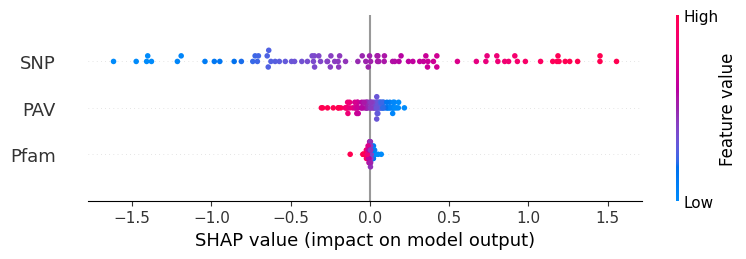

In [242]:
shap.summary_plot(shap_values_meta, meta_features_test, feature_names=["SNP", "PAV", "Pfam"], show=False)
plt.savefig(
    "stack_model_varthreshold_yield_withenv.png",
    dpi=600,
    bbox_inches="tight"
)